In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import functools
import re
from pathlib import Path
conn = duckdb.connect()
@functools.lru_cache(maxsize=1024)
def q(query: str):
    return conn.execute(query).df()

In [10]:
pattern = re.compile(r'^(\d+)_cf_a_([0-9.]+)')
rows = []
for p in Path('../results/zonestats').glob('*.csv'):
    m = pattern.match(p.stem)
    if not m:
        continue
    df_part = pd.read_csv(p, skiprows=1)
    df_part['i'] = int(m.group(1))
    df_part['label'] = 'a'
    df_part['threshold'] = float(m.group(2))
    rows.append(df_part)
df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
df['amp_lower'] = df['rv_wasted'] / df['misses']
df['amp_upper'] = (df['rv_fetch'] - df['rv_good'])/ df['misses']
df['amp_mid'] = (df['amp_lower'] + df['amp_upper']) / 2
df

,zone,requests,hits,misses,rv_fetch,rv_good,rv_wasted,i,label,threshold,amp_lower,amp_upper,amp_mid
0,17631565413542352426,3043,1452,1591,1,0,1,2,a,0.65,0.000629,0.000629,0.000629
1,15692541335355566438,6973,6524,449,377,322,55,2,a,0.65,0.122494,0.122494,0.122494
2,17281823974450286159,45726,35069,10657,3635,2235,1398,2,a,0.65,0.131181,0.131369,0.131275
3,15674276794419435660,3782,3690,92,80,67,13,2,a,0.65,0.141304,0.141304,0.141304
4,13484831603253968014,61910,59916,1994,80,34,45,2,a,0.65,0.022568,0.023069,0.022818
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75615,18193381277962664283,3272,3257,15,0,0,0,3,a,0.75,0.000000,0.000000,0.000000
75616,8959347944816003841,12647,12202,445,0,0,0,3,a,0.75,0.000000,0.000000,0.000000
75617,1740226554720156041,252561,251833,728,135,107,28,3,a,0.75,0.038462,0.038462,0.038462
75618,2111892004584153962,17818,1310,16508,0,0,0,3,a,0.75,0.000000,0.000000,0.000000


<Axes: >

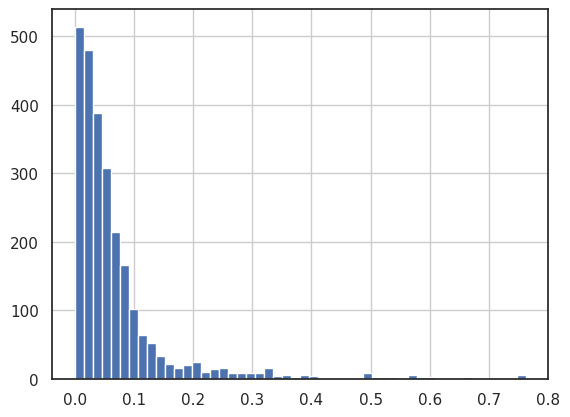

In [ ]:
sdf = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['amp_mid', 'threshold'])[(df['threshold'] == 0.8) & (df['rv_fetch'] > 100) & (df['rv_fetch'] / df['misses'] > 0.01)]
sdf['amp_mid'].hist(bins=50)

In [8]:
df.threshold.unique()

array([0.65, 0.95, 1.  , 0.9 , 0.85, 0.6 , 0.7 , 0.8 , 0.75, 0.55])

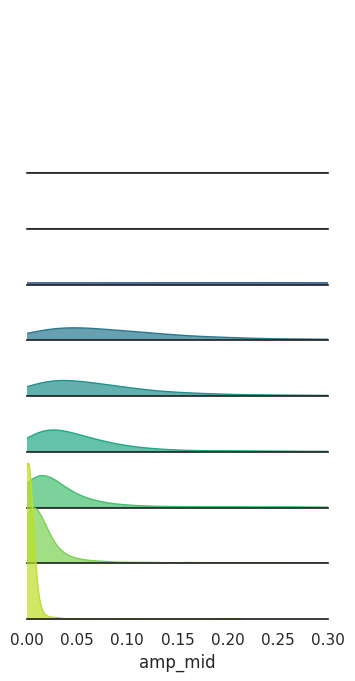

,zone,requests,hits,misses,rv_fetch,rv_good,rv_wasted,i,label,threshold,amp_lower,amp_upper,amp_mid,amp_binned
1,15692541335355566438,6973,6524,449,377,322,55,2,a,0.65,0.122494,0.122494,0.122494,0.1225
2,17281823974450286159,45726,35069,10657,3635,2235,1398,2,a,0.65,0.131181,0.131369,0.131275,0.1325
5,2943289232075968697,135229,113955,21274,7782,4550,3232,2,a,0.65,0.151923,0.151923,0.151923,0.1525
12,7456078612563528163,5597,3700,1897,437,227,205,2,a,0.65,0.108065,0.110701,0.109383,0.1075
13,18439339316868257486,4290,4042,248,219,158,61,2,a,0.65,0.245968,0.245968,0.245968,0.2475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75608,11671451169506299616,5945,5321,624,1356,1199,157,3,a,0.75,0.251603,0.251603,0.251603,0.2525
75610,7014337124216984406,28028,9386,18642,1225,720,499,3,a,0.75,0.026768,0.027089,0.026928,0.0275
75612,9841171007136308090,6378,2731,3647,324,184,136,3,a,0.75,0.037291,0.038388,0.037839,0.0375
75617,1740226554720156041,252561,251833,728,135,107,28,3,a,0.75,0.038462,0.038462,0.038462,0.0375


/tmp/ipykernel_899436/253751812.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = cdf.groupby(['threshold', 'amp_binned']).size().unstack(fill_value=0)


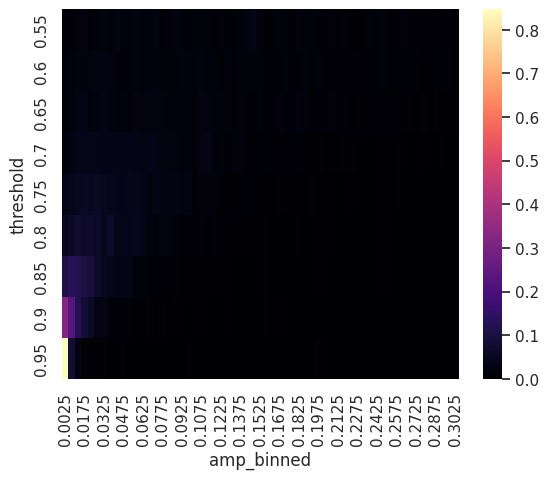

In [71]:
cdf = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['amp_mid', 'threshold'])
cdf = cdf[(cdf['rv_fetch'] > 100) & (cdf['rv_fetch'] / cdf['misses'] > 0.01) & (cdf['threshold'] >= 0.55)]
order = sorted(cdf['threshold'].unique())

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(cdf, row='threshold', row_order=order, hue='threshold', aspect=5, height=.8, palette='viridis', sharey=True)
g.map(sns.kdeplot, 'amp_mid', fill=True, alpha=0.7, bw_adjust=1)
g.figure.subplots_adjust(hspace=-.66) # Overlap effect
# g.map(plt.axhline, y=0, lw=0.5, color='gray', clip_on=False)
# g.set_titles(row_template='threshold={row_name}')
g.set_titles('')
# g.set(yscale='log')
g.set(yticks=[], ylabel='')
g.set(xlim=(0, 0.3))
g.despine(left=True)
plt.show()

cdf['amp_binned'] = pd.cut(cdf['amp_mid'], bins=np.arange(0, 0.31, 0.005)).apply(lambda x: x.mid)
display(cdf)
pivot_table = cdf.groupby(['threshold', 'amp_binned']).size().unstack(fill_value=0)
pivot_norm = pivot_table.div(pivot_table.sum(axis=1), axis=0)
h = sns.heatmap(pivot_norm, cmap='magma')

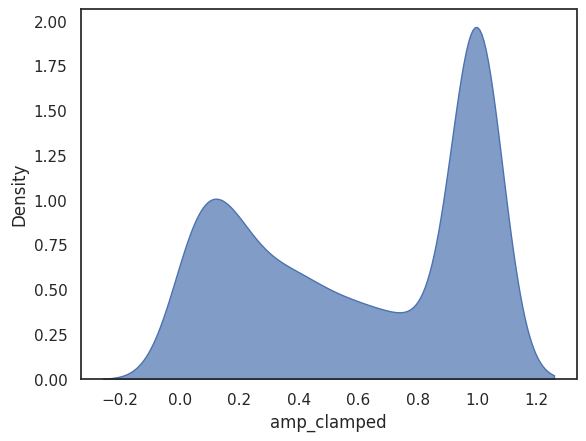

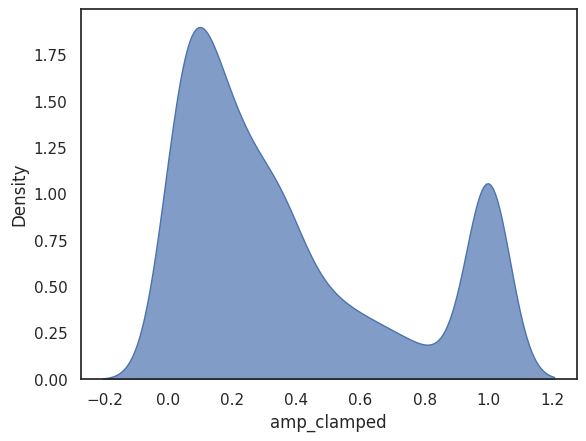

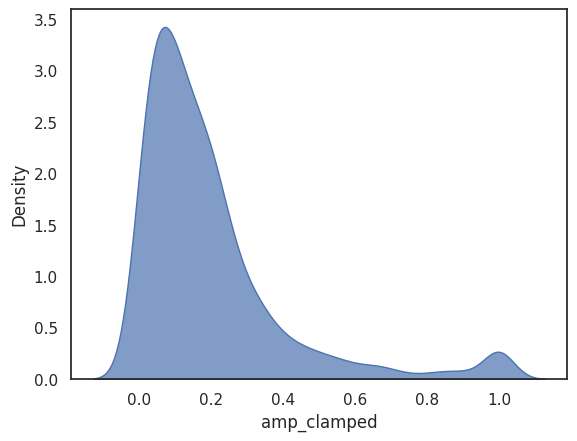

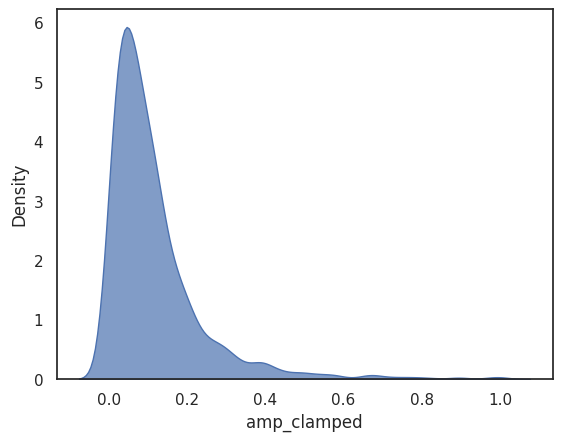

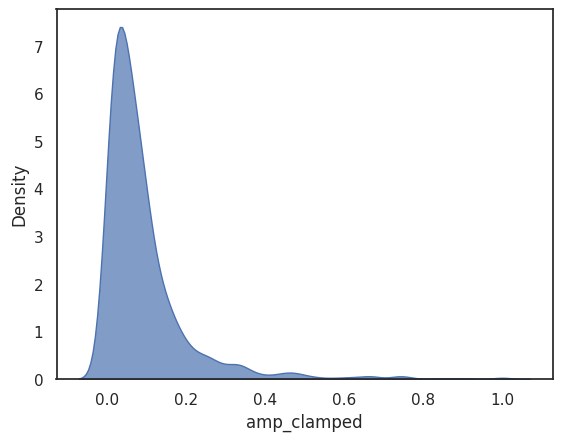

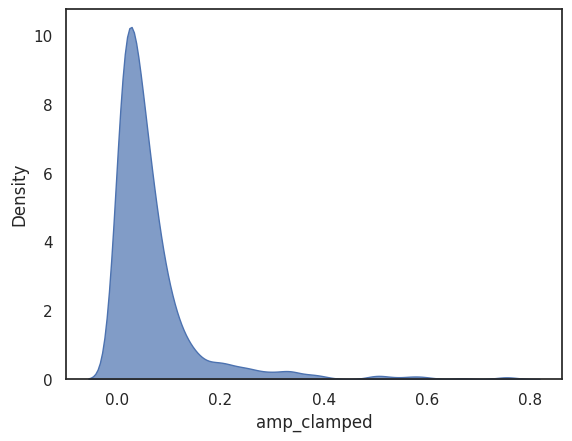

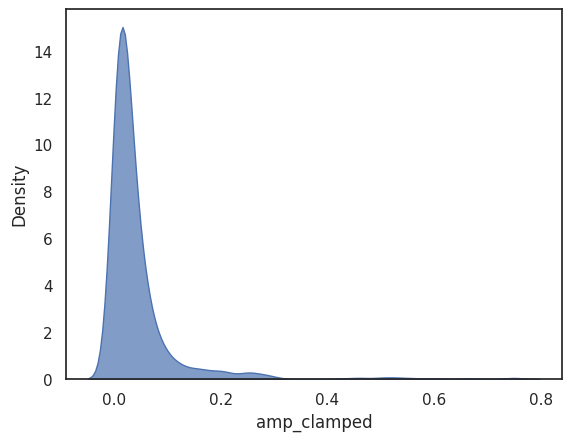

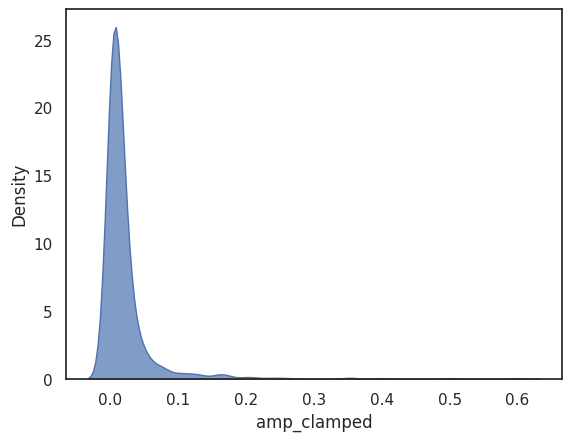

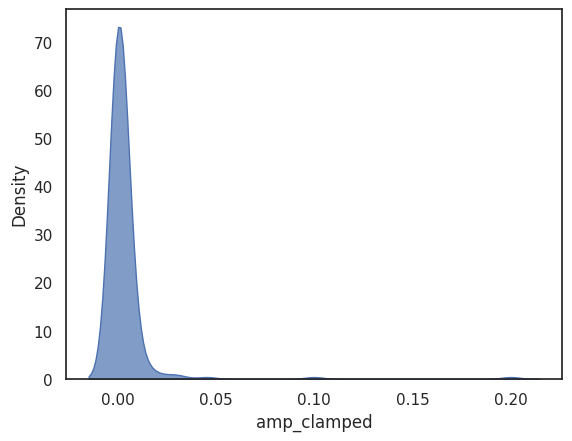

In [88]:
cdf['amp_clamped'] = cdf['amp_mid'].clip(0, 1)
for t in order:
    sns.kdeplot(cdf[cdf['threshold'] == t]['amp_clamped'], fill=True, alpha=0.7, bw_adjust=1, label=f'threshold={t}', common_norm=False)
    plt.show()

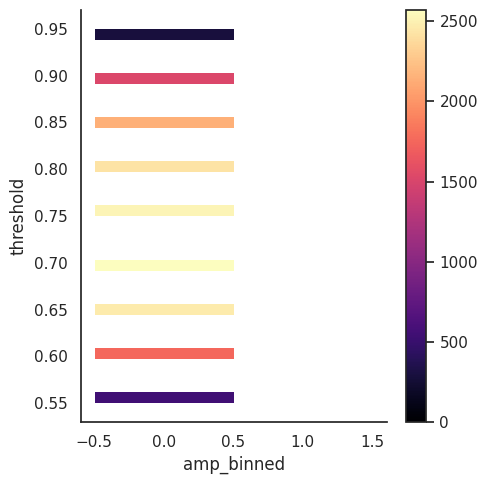

In [72]:
sns.displot(
    data=cdf, x="amp_binned", y="threshold", 
    # log_scale=(False, True), 
    cbar=True, cmap="magma"
)